In [1]:

import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
import pandas as pd
import seaborn as sn

In [2]:

def predict(pi, mu, sigmasq):
    n, k = pi.shape
    _, kt = mu.shape
    t = 1#int(kt / k)  # label dim
    _, max_component = torch.max(pi, 1)  # Get index of max mixture component
    mu_est = Variable(torch.zeros(n, t))
    sigma_est = Variable(torch.zeros(n, t))
    k_est = Variable(torch.zeros(n, t))
    for i in range(n):
        for j in range(t):
            mu_est[i, j] = mu[i, max_component.data[i] * t + j]
            sigma_est[i, j] = torch.sqrt(sigmasq[i, max_component.data[i] * t + j])
            k_est[i, j] = max_component.data[i] * t + j
    return mu_est, sigma_est, k_est


def forward(x):
    out = F.tanh(x.mm(w1) + b1)  # shape (n, d) -> (n, h)
    pi = F.softmax(out.mm(w_pi) + b_pi, dim=1)  # shape (n, h) -> (n, d_pi)
    sigmasq = torch.exp(out.mm(w_sigmasq) + b_sigmasq)  # shape (n, h) -> (n, d_sigmasq)
    mu = out.mm(w_mu) + b_mu  # shape (n, h) -> (n, d_mu)
    return pi, sigmasq, mu


def gaussian_pdf(x, mu, sigmasq):
    return (1 / torch.sqrt(2 * np.pi * sigmasq)) * torch.exp(
        (-1 / (2 * sigmasq)) * torch.norm((x - mu), 2, 1) ** 2
    )


def loss_fn(pi, sigmasq, mu, target):
    t=1
    losses = Variable(torch.zeros(len(target)))
    for i in range(k):
        likelihood_z_x = gaussian_pdf(target, mu[:, i * t : (i + 1) * t], sigmasq[:, i])
        losses += pi[:, i] * likelihood_z_x

    return -torch.sum(torch.log(losses))


def train(data_df, epochs = 1000, lr=0.008):
    opt = optim.Adam([w1, b1, w_pi, b_pi, w_sigmasq, b_sigmasq, w_mu, b_mu], lr=lr)
    n = len(data_df)
    x_train = torch.tensor(data_df["x_norm"]).reshape(n, 1).to(torch.float32)
    y_train = torch.tensor(data_df["y_norm"]).reshape(n, 1).to(torch.float32)
    x = Variable(x_train)
    y = Variable(y_train)
    losses = np.zeros(epochs)

    for epoch in range(epochs):
        opt.zero_grad()
        pi, sigmasq, mu = forward(x)
        loss = loss_fn(pi, sigmasq, mu, y)
        losses[epoch] = loss.detach().numpy()
        loss.backward()
        opt.step()
    
    return losses


def main(train_df, test_df, epochs = 1000, lr=0.008, normalize=True):
    # Normalize
    if normalize:
        x_mean = train_df["x"].mean()
        x_std = train_df["x"].std()
        y_mean = train_df["y"].mean()
        y_std = train_df["y"].std()
    else:
        x_mean, y_mean = (0,0)
        x_std, y_std = (1,1)

    train_df["x_norm"] = (train_df["x"]-x_mean)/x_std
    train_df["y_norm"] = (train_df["y"]-y_mean)/y_std
    test_df["x_norm"] = (test_df["x"]-x_mean)/x_std
    test_df["y_norm"] = (test_df["y"]-y_mean)/y_std
    
    # Train
    training_losses = train(train_df, epochs = epochs, lr=lr)

    # Prediction
    x_test = test_df["x_norm"].values.reshape(len(test_df), 1)
    print(x_test.shape)
    pi, sigmasq, mu = forward(Variable(torch.from_numpy(x_test)))
    preds, sigmas, k_argmax = predict(pi, mu, sigmasq)
    k_mixture = mu.shape[1]
    
    test_df["y_est"] = preds.detach().numpy()*y_std + y_mean
    test_df["sigma_est"] = sigmas.detach().numpy()*y_std
    test_df["k_argmax"] = k_argmax.detach().numpy()
    test_df["y_exp"] = 0
    test_df["var_exp"] = 0
    for i in range(k_mixture):
        test_df[f"mu_{i}"] = mu.detach().numpy()[:,i]*y_std + y_mean
        test_df[f"var_{i}"] = sigmasq.detach().numpy()[:,i]*y_std**2
        test_df[f"sigma_{i}"] = np.sqrt(sigmasq.detach().numpy()[:,i])*y_std
        test_df[f"pi_{i}"] = pi.detach().numpy()[:,i]
        test_df["y_exp"] = test_df["y_exp"] + test_df[f"mu_{i}"]*test_df[f"pi_{i}"]
    for i in range(k_mixture):
        test_df["var_exp"] = test_df["var_exp"] + test_df[f"var_{i}"]*test_df[f"pi_{i}"] + test_df[f"pi_{i}"]*(test_df[f"mu_{i}"] - test_df["y_exp"])**2
    test_df["sigma_exp"] = np.sqrt(test_df["var_exp"])
    test_df["var_fair"] = test_df["var_exp"] + (test_df["y_exp"] - test_df["y_est"])**2
    test_df["sigma_fair"] = np.sqrt(test_df["var_fair"])
    
    return training_losses, test_df


In [3]:
def generate_linear_data(x_min, x_max, a=2, b=0.1, sigma=0.2, N=1000):
    rng = np.random.default_rng()
    epsilons = rng.normal(0, sigma, N).astype(np.float32)
    x = np.linspace(x_min, x_max, num=N).astype(np.float32)
    #x = rng.normal(0, 5, N)
    mu = a + b*x
    y = mu + epsilons
    return x, y, mu


def s_shape_data(N=1000, sigma=0.1):
    d = 1
    xs = np.random.uniform(0, 1, (N, d)).astype(np.float32)
    noise = np.random.uniform(-sigma, sigma, (N, d)).astype(np.float32)
    ys_mu = xs + 0.3 * np.sin(2 * np.pi * xs)
    ys = ys_mu + noise
    x_train = ys
    y_train = xs
    data_df = pd.DataFrame({"x":x_train.flatten(), "y": y_train.flatten(), "y_mu": ys_mu.flatten()})
    data_df = data_df.sort_values(by="x")
    return data_df

def double_linear_data(x_min=-10, x_max=10, a=2, b=0.1, sigma=0.2, N=1000):
    data_x1, data_y1, y_mu1 = generate_linear_data(x_min, x_max, N=int(N*0.6), b=0.1, sigma=1)
    data_x2, data_y2, y_mu2 = generate_linear_data(x_min, x_max, N=int(N*0.4),  b=1, sigma=0.5)
    data_df = pd.DataFrame({"x":np.concatenate([data_x1, data_x2]), "y": np.concatenate([data_y1, data_y2]), "y_mu": np.concatenate([y_mu1, y_mu2])})
    data_df = data_df.sort_values(by="x")
    return data_df

In [4]:
def plot_data(data_df, plot_mu=False):
    fig, ax = plt.subplots(figsize=(8,6))
    sn.scatterplot(data_df, x="x", y="y", ax=ax, label="Sampled values", alpha=1, s = 50)
    if plot_mu:
        sn.lineplot(data_df, x="x", y="y_mu", color="black", linestyle="--", linewidth=2, label=r"$\mu(x)$")
    ax.grid(True)
    ax.set_xlabel("X", fontsize=16)
    ax.set_ylabel("Y", fontsize=16)
    ax.legend(fontsize=14)
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=14)

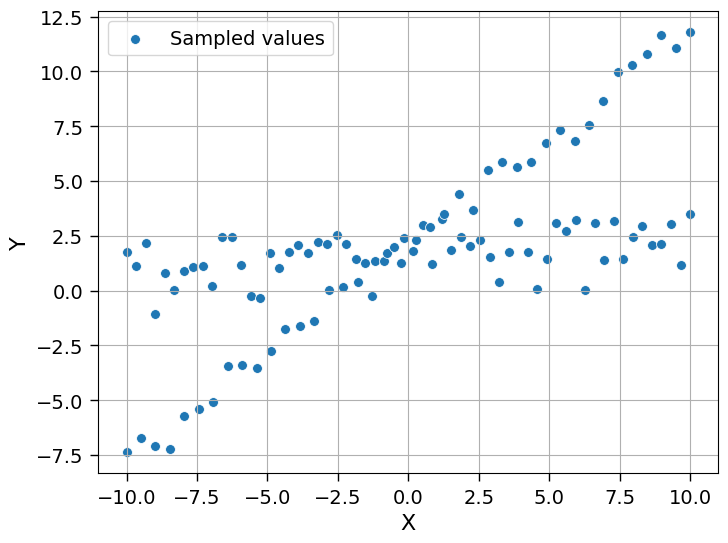

In [5]:

# generate data
train_df = double_linear_data(N=3000, sigma=0.4)
test_df = double_linear_data(N=100, sigma=0.4)

plot_data(test_df)


In [6]:

d_y = 1 # dimensions of Y
d_x = 1 # Dimensions of X
n_hidden = 10  # Dimension of hidden layer
k = 3  # Number of mixing coefficients
d_pi = k
d_sigmasq = k

# Set hyperparameters
epochs = 4000
lr = 0.01

# Initialize parameters

d_mu = d_y * k
w1 = Variable(torch.randn(d_x, n_hidden) * np.sqrt(2 / (d_x + n_hidden)), requires_grad=True)
b1 = Variable(torch.zeros(1, n_hidden), requires_grad=True)
w_pi = Variable(torch.randn(n_hidden, d_pi) * np.sqrt(2 / (d_x + n_hidden)), requires_grad=True)
b_pi = Variable(torch.zeros(1, d_pi), requires_grad=True)
w_sigmasq = Variable(
    torch.randn(n_hidden, d_sigmasq) * np.sqrt(2 / (d_x + n_hidden)), requires_grad=True
)
b_sigmasq = Variable(torch.zeros(1, d_sigmasq), requires_grad=True)
w_mu = Variable(torch.randn(n_hidden, d_mu) * np.sqrt(2 / (d_x + n_hidden)), requires_grad=True)
b_mu = Variable(torch.zeros(1, d_mu), requires_grad=True)

In [7]:
losses, test_df = main(train_df, test_df, epochs=epochs, lr=lr, normalize=True)

(100, 1)


/tmp/ipykernel_282317/366671649.py:83: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  pi, sigmasq, mu = forward(Variable(torch.from_numpy(x_test)))


(1112.50341796875, 1222.50341796875)

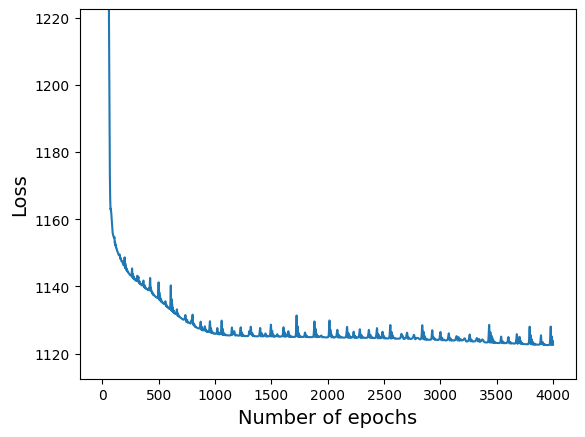

In [8]:
epoch_list = np.arange(0, epochs)
plt.plot(epoch_list, losses)
plt.xlabel("Number of epochs", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.ylim(np.min(losses)-10, np.min(losses)+100)

In [9]:
test_df

,x,y,y_mu,x_norm,y_norm,y_est,sigma_est,k_argmax,y_exp,var_exp,...,var_1,sigma_1,pi_1,mu_2,var_2,sigma_2,pi_2,sigma_exp,var_fair,sigma_fair
0,-10.000000,1.753172,1.000000,-1.730608,-0.066051,1.199452,1.045431,1.0,-2.433262,20.389044,...,1.092925,1.045431,0.526637,-7.945435,0.202782,0.450313,0.392862,4.515423,33.585653,5.795313
60,-10.000000,-7.374514,-8.000000,-1.730608,-2.484215,1.199452,1.045431,1.0,-2.433262,20.389044,...,1.092925,1.045431,0.526637,-7.945435,0.202782,0.450313,0.392862,4.515423,33.585653,5.795313
1,-9.661017,1.109615,1.033898,-1.671943,-0.236546,1.201043,1.044756,1.0,-2.320420,19.165455,...,1.091515,1.044756,0.522657,-7.645218,0.206714,0.454658,0.394106,4.377837,31.566156,5.618377
61,-9.487180,-6.748107,-7.487180,-1.641859,-2.318264,1.202717,1.044289,1.0,-2.260810,18.546722,...,1.090540,1.044289,0.520520,-7.488619,0.208785,0.456930,0.394774,4.306591,30.542742,5.526549
2,-9.322034,2.183536,1.067797,-1.613279,0.047964,1.204835,1.043766,1.0,-2.203064,17.964809,...,1.089448,1.043766,0.518432,-7.338238,0.210786,0.459114,0.395424,4.238491,29.578589,5.438620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,9.322034,3.049289,2.932203,1.613279,0.277324,3.000808,0.835012,0.0,6.184651,18.332337,...,0.741429,0.861063,0.105069,11.379921,0.255549,0.505519,0.395644,4.281628,28.469190,5.335653
98,9.487180,11.064248,11.487180,1.641859,2.400698,3.001726,0.832736,0.0,6.241314,18.946226,...,0.751254,0.866749,0.100373,11.544445,0.256061,0.506025,0.394022,4.352726,29.441157,5.425971
58,9.661017,1.169590,2.966102,1.671943,-0.220657,3.002528,0.830395,0.0,6.298577,19.596224,...,0.761828,0.872827,0.095661,11.716090,0.256640,0.506597,0.392212,4.426762,30.460162,5.519073
59,10.000000,3.486996,3.000000,1.730608,0.393285,3.003538,0.826010,0.0,6.403117,20.871707,...,0.783044,0.884898,0.087147,12.045816,0.257882,0.507821,0.388408,4.568556,32.428845,5.694633


(0.0, 1.0)

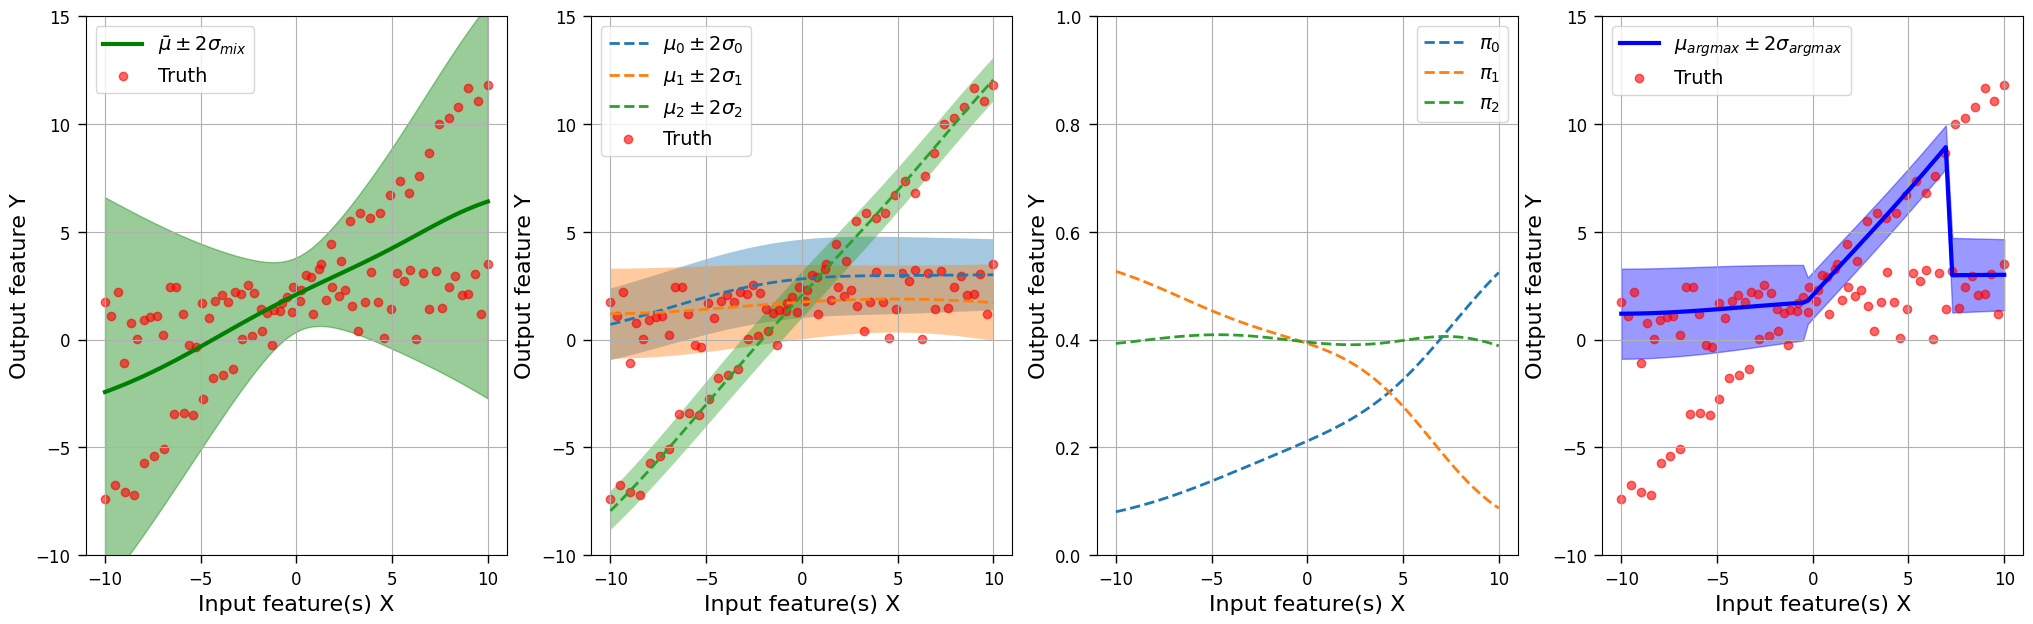

In [10]:
fig, axs = plt.subplots(ncols=4, figsize=(25,7))

axs[0].plot(test_df["x"], test_df["y_exp"], linewidth=3, label=r"$\bar{\mu} \pm 2\sigma_{mix}$", color="green")
axs[0].fill_between(test_df["x"], test_df["y_exp"]-2*test_df["sigma_exp"], test_df["y_exp"]+2*test_df["sigma_exp"], alpha=0.4, color="green")
axs[0].scatter(test_df["x"], test_df["y"], label="Truth", alpha=0.6, color="red")

axs[3].plot(test_df["x"], test_df["y_est"], linewidth=3, label=r"$\mu_{argmax} \pm 2\sigma_{argmax}$", color="blue")
axs[3].fill_between(test_df["x"], test_df["y_est"]-2*test_df["sigma_est"], test_df["y_est"]+2*test_df["sigma_est"], alpha=0.4, color="blue")
axs[3].scatter(test_df["x"], test_df["y"], label="Truth", alpha=0.6, color="red")

#axs[2].plot(test_df["x"], test_df["y_est"], linewidth=3, label=r"$\mu_{argmax}$", color="blue")
#axs[2].fill_between(test_df["x"], test_df["y_exp"]-2*test_df["sigma_fair"], test_df["y_exp"]+2*test_df["sigma_fair"], alpha=0.4, label=r"$\mu_{argmax} \pm 2\sigma_{fair}$", color="grey")


for i in range(k):
    axs[1].plot(test_df["x"], test_df[f"mu_{i}"], linestyle="--", linewidth=2, label = rf"$\mu_{i} \pm 2\sigma_{i}$")
    axs[1].fill_between(test_df["x"], test_df[f"mu_{i}"]-2*test_df[f"sigma_{i}"], test_df[f"mu_{i}"]+2*test_df[f"sigma_{i}"], alpha=0.4)
axs[1].scatter(test_df["x"], test_df["y"], label="Truth", alpha=0.6, color="red")

for i in range(k):
    axs[2].plot(test_df["x"], test_df[f"pi_{i}"], linestyle="--", linewidth=2, label = rf"$\pi_{i}$")
    #axs[2].fill_between(test_df["x"], test_df[f"pi_{i}"]-2*test_df[f"sigma_{i}"], test_df[f"mu_{i}"]+2*test_df[f"sigma_{i}"], alpha=0.4)


for ax in axs:
    ax.legend(fontsize=14)
    ax.set_ylim(-10, 15)
    ax.set_xlabel("Input feature(s) X", fontsize=16)
    #ax.set_ylim(-0.2,1.5)
    ax.set_ylabel("Output feature Y", fontsize=16)
    ax.tick_params(which="major", direction="out", bottom=True, left=True, pad=5, length=6, width=1, labelsize=12)
    ax.grid(True)
    
axs[2].set_ylim(0,1)


Text(0, 0.5, 'Y')

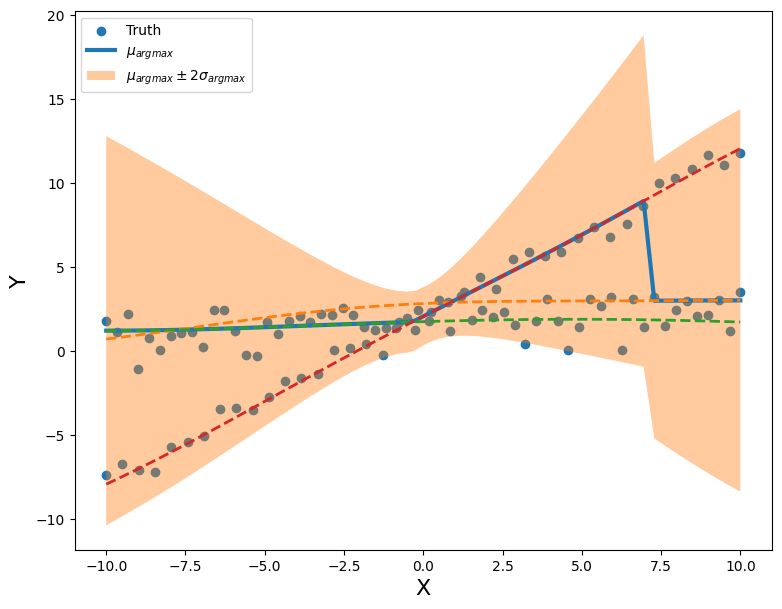

In [11]:
fig, ax = plt.subplots(figsize=(9,7))

ax.scatter(test_df["x"], test_df["y"], label="Truth")
ax.plot(test_df["x"], test_df["y_est"], linewidth=3, label=r"$\mu_{argmax}$")
ax.fill_between(test_df["x"], test_df["y_est"]-2*test_df["sigma_fair"], test_df["y_est"]+2*test_df["sigma_fair"], alpha=0.4, label=r"$\mu_{argmax} \pm 2\sigma_{argmax}$")
for i in range(k):
    ax.plot(test_df["x"], test_df[f"mu_{i}"], linestyle="--", linewidth=2)
ax.legend()
#ax.set_ylim(-0.2,1.5)
ax.set_xlabel("X", fontsize=16)
#ax.set_ylim(-0.2,1.5)
ax.set_ylabel("Y", fontsize=16)


Text(0, 0.5, 'Y')

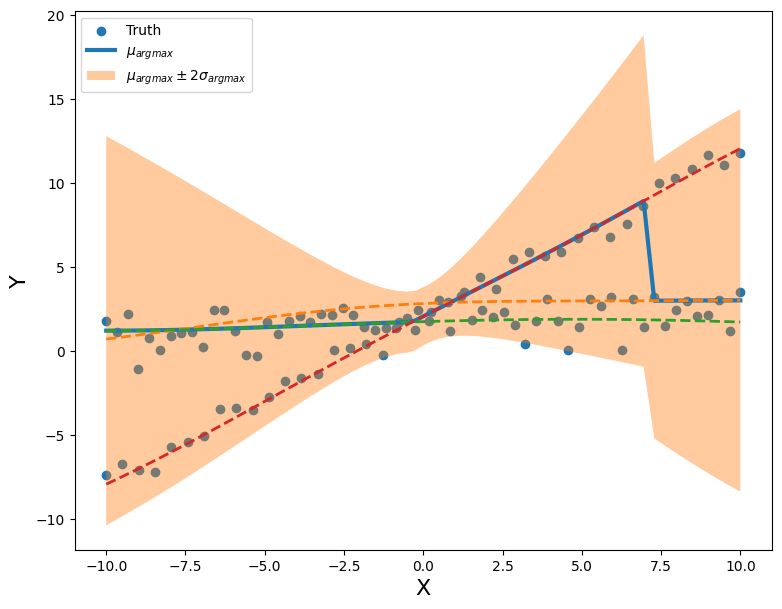

In [12]:
fig, ax = plt.subplots(figsize=(9,7))

ax.scatter(test_df["x"], test_df["y"], label="Truth")
ax.plot(test_df["x"], test_df["y_est"], linewidth=3, label=r"$\mu_{argmax}$")
ax.fill_between(test_df["x"], test_df["y_est"]-2*test_df["sigma_fair"], test_df["y_est"]+2*test_df["sigma_fair"], alpha=0.4, label=r"$\mu_{argmax} \pm 2\sigma_{argmax}$")
for i in range(k):
    ax.plot(test_df["x"], test_df[f"mu_{i}"], linestyle="--", linewidth=2)
ax.legend()
#ax.set_ylim(-0.2,1.5)
ax.set_xlabel("X", fontsize=16)
#ax.set_ylim(-0.2,1.5)
ax.set_ylabel("Y", fontsize=16)
